Columns in dataset: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']
Training with Batch GD...
Training with Stochastic GD...
Training with Mini-Batch GD...
Training with Momentum...
Training with Nesterov...


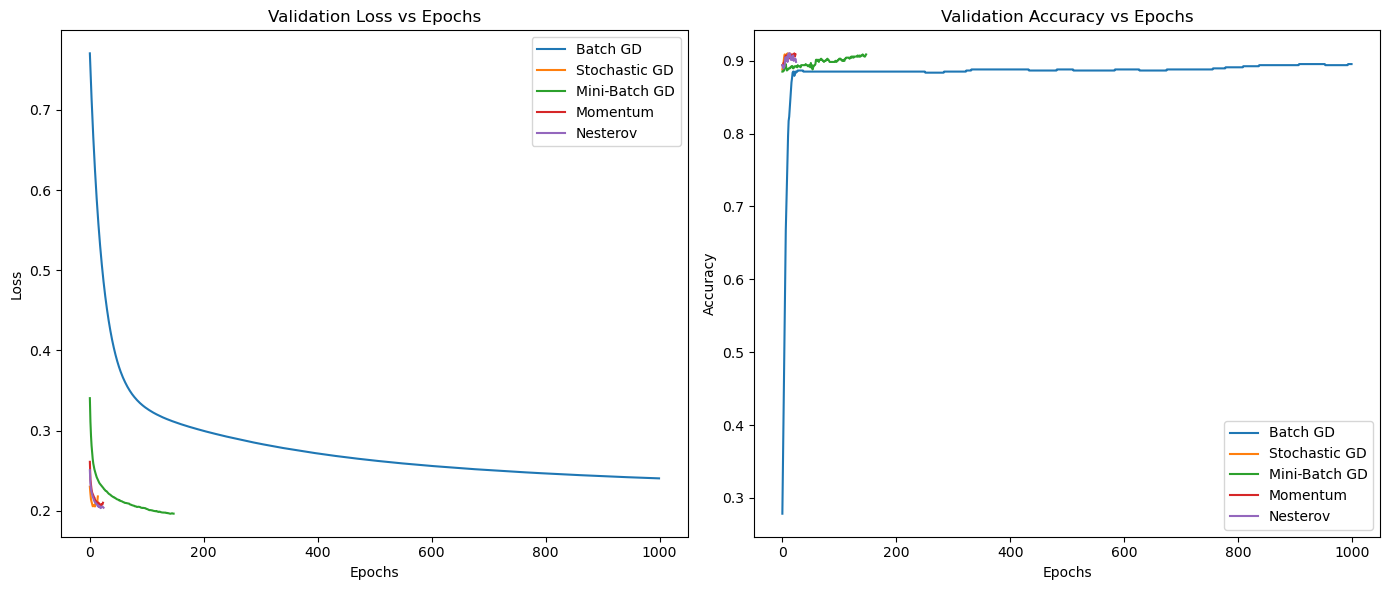

Training Mini-Batch GD with batch size 16...
Training Mini-Batch GD with batch size 32...
Training Mini-Batch GD with batch size 64...


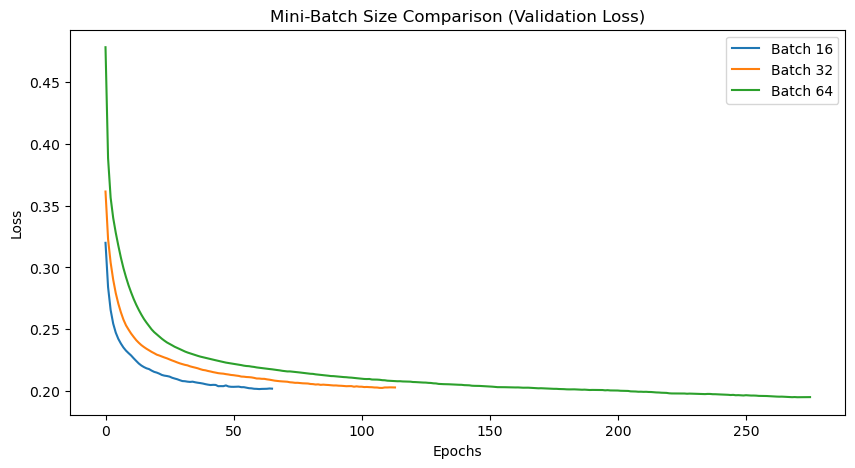

Training SGD with learning rate 0.1...
Training SGD with learning rate 0.01...
Training SGD with learning rate 0.001...


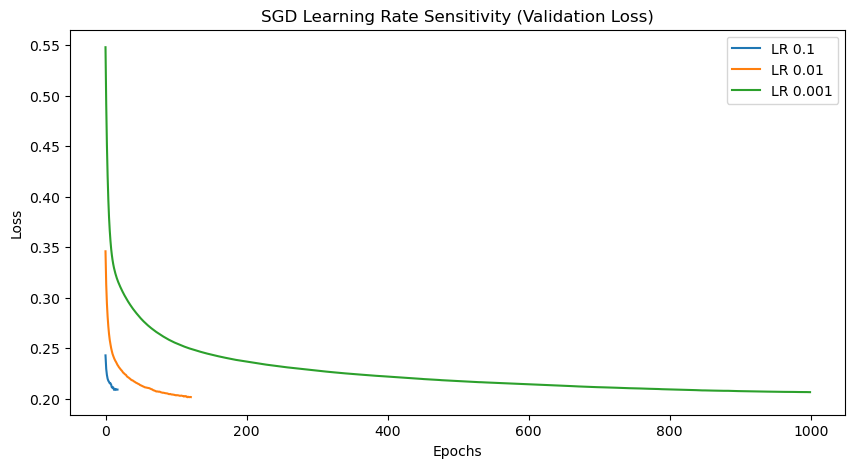

Training Momentum with momentum 0.5...
Training Nesterov with momentum 0.5...
Training Momentum with momentum 0.9...
Training Nesterov with momentum 0.9...
Training Momentum with momentum 0.99...
Training Nesterov with momentum 0.99...


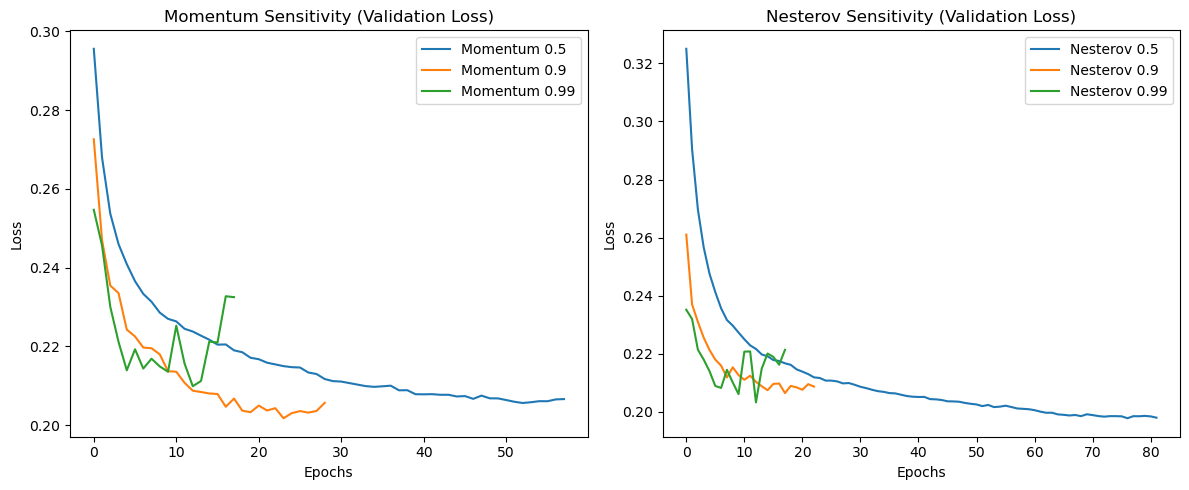

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

Best Optimizer: Stochastic GD
Test Accuracy: 0.8984
Test Precision: 0.6216
Test Recall: 0.2949
Test F1-score: 0.4000
Confusion Matrix:
 [[587  14]
 [ 55  23]]

Optimizer Comparison Summary:
       Optimizer  Final Train Loss  Final Val Loss  Best Val Accuracy  \
0       Batch GD          0.267293        0.240278           0.895434   
1  Stochastic GD          0.195050        0.217729           0.910162   
2  Mini-Batch GD          0.204330        0.196251           0.908689   
3       Momentum          0.198753        0.209846           0.910162   
4       Nesterov          0.199985        0.203666           0.910162   

   Training Time (s)  
0         165.443433  
1          87.308550  
2          45.909293  
3           7.971832  
4           8.302459  


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import SGD

# -----------------------------
# 1. Reproducibility
# -----------------------------
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# -----------------------------
# 2. Load Dataset
# -----------------------------
data_path = r"Z:\bank details.csv"  # YOUR DATASET PATH

if not os.path.exists(data_path):
    raise FileNotFoundError("Dataset not found at Z:\\bank details.csv")

df = pd.read_csv(data_path, sep=',')

print("Columns in dataset:", df.columns.tolist())

# -----------------------------
# 3. Target Variable
# -----------------------------
TARGET = 'y'
if TARGET not in df.columns:
    raise ValueError("❌ Target column 'y' not found.")

df[TARGET] = df[TARGET].map({'yes': 1, 'no': 0, 'Yes': 1, 'No': 0})

# -----------------------------
# 4. Preprocessing
# -----------------------------
X = df.drop(columns=[TARGET])
y = df[TARGET]

categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# Fit-transform entire dataset
X_processed = preprocessor.fit_transform(X)

# -----------------------------
# 5. Train / Validation / Test Split (70 / 15 / 15)
# -----------------------------
X_temp, X_test, y_temp, y_test = train_test_split(
    X_processed, y, test_size=0.15, random_state=SEED, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=SEED, stratify=y_temp
)  # 0.1765 of 85% ≈ 15%

input_dim = X_train.shape[1]

# -----------------------------
# 6. Model Architecture
# -----------------------------
from tensorflow.keras.layers import Input

def build_model():
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    return model



# -----------------------------
# 7. Training Function
# -----------------------------
def train_model(optimizer, batch_size):
    model = build_model()
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    start_time = time.time()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        batch_size=batch_size,
        epochs=1000,
        callbacks=[early_stop],
        verbose=0
    )
    training_time = time.time() - start_time

    return model, history, training_time

# -----------------------------
# 8. Optimizer Configurations
# -----------------------------
optimizers = {
    "Batch GD": SGD(learning_rate=0.01),
    "Stochastic GD": SGD(learning_rate=0.01),
    "Mini-Batch GD": SGD(learning_rate=0.01),
    "Momentum": SGD(learning_rate=0.01, momentum=0.9),
    "Nesterov": SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
}

batch_sizes = {
    "Batch GD": X_train.shape[0],
    "Stochastic GD": 1,
    "Mini-Batch GD": 32,
    "Momentum": 32,
    "Nesterov": 32
}

results = {}

# -----------------------------
# 9. Train All Optimizers
# -----------------------------
for name, optimizer in optimizers.items():
    print(f"Training with {name}...")
    model, history, train_time = train_model(
        optimizer, batch_sizes[name]
    )
    results[name] = {
        "model": model,
        "history": history,
        "time": train_time
    }

# -----------------------------
# 10. Plot Loss and Validation Accuracy
# -----------------------------
plt.figure(figsize=(14, 6))

# Validation Loss
plt.subplot(1, 2, 1)
for name, res in results.items():
    plt.plot(res["history"].history['val_loss'], label=name)
plt.title("Validation Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# Validation Accuracy
plt.subplot(1, 2, 2)
for name, res in results.items():
    plt.plot(res["history"].history['val_accuracy'], label=name)
plt.title("Validation Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

# -----------------------------
# 11. Mini-Batch Size Experiment
# -----------------------------
mini_batch_sizes = [16, 32, 64]
mini_batch_results = {}

for bs in mini_batch_sizes:
    print(f"Training Mini-Batch GD with batch size {bs}...")
    optimizer = SGD(learning_rate=0.01)
    model, history, train_time = train_model(optimizer, bs)
    mini_batch_results[bs] = {
        "model": model,
        "history": history,
        "time": train_time
    }

plt.figure(figsize=(10, 5))
for bs, res in mini_batch_results.items():
    plt.plot(res["history"].history['val_loss'], label=f"Batch {bs}")
plt.title("Mini-Batch Size Comparison (Validation Loss)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# -----------------------------
# 12. Hyperparameter Sensitivity
# -----------------------------
# Learning rate sensitivity for SGD
learning_rates = [0.1, 0.01, 0.001]
sgd_lr_results = {}

for lr in learning_rates:
    print(f"Training SGD with learning rate {lr}...")
    optimizer = SGD(learning_rate=lr)
    model, history, train_time = train_model(optimizer, 32)
    sgd_lr_results[lr] = {
        "model": model,
        "history": history,
        "time": train_time
    }

plt.figure(figsize=(10, 5))
for lr, res in sgd_lr_results.items():
    plt.plot(res["history"].history['val_loss'], label=f"LR {lr}")
plt.title("SGD Learning Rate Sensitivity (Validation Loss)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Momentum coefficient sensitivity
momentum_values = [0.5, 0.9, 0.99]
momentum_results = {}
nesterov_results = {}

for m in momentum_values:
    print(f"Training Momentum with momentum {m}...")
    optimizer = SGD(learning_rate=0.01, momentum=m)
    model, history, train_time = train_model(optimizer, 32)
    momentum_results[m] = {
        "model": model,
        "history": history,
        "time": train_time
    }

    print(f"Training Nesterov with momentum {m}...")
    optimizer = SGD(learning_rate=0.01, momentum=m, nesterov=True)
    model, history, train_time = train_model(optimizer, 32)
    nesterov_results[m] = {
        "model": model,
        "history": history,
        "time": train_time
    }

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for m, res in momentum_results.items():
    plt.plot(res["history"].history['val_loss'], label=f"Momentum {m}")
plt.title("Momentum Sensitivity (Validation Loss)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
for m, res in nesterov_results.items():
    plt.plot(res["history"].history['val_loss'], label=f"Nesterov {m}")
plt.title("Nesterov Sensitivity (Validation Loss)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

# -----------------------------
# 13. Final Evaluation on Test Set (Best Optimizer)
# -----------------------------
best_name = None
best_val_acc = 0

for name, res in results.items():
    val_acc = max(res["history"].history['val_accuracy'])
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_name = name

best_model = results[best_name]["model"]

# Predict on test set
y_test_pred_prob = best_model.predict(X_test).ravel()
y_test_pred = (y_test_pred_prob >= 0.5).astype(int)

# Metrics
acc = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred)
rec = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
cm = confusion_matrix(y_test, y_test_pred)

print("\nBest Optimizer:", best_name)
print(f"Test Accuracy: {acc:.4f}")
print(f"Test Precision: {prec:.4f}")
print(f"Test Recall: {rec:.4f}")
print(f"Test F1-score: {f1:.4f}")
print("Confusion Matrix:\n", cm)

# -----------------------------
# 14. Summary Table
# -----------------------------
summary = []

for name, res in results.items():
    history = res["history"]
    summary.append({
        "Optimizer": name,
        "Final Train Loss": history.history['loss'][-1],
        "Final Val Loss": history.history['val_loss'][-1],
        "Best Val Accuracy": max(history.history['val_accuracy']),
        "Training Time (s)": res["time"]
    })

summary_df = pd.DataFrame(summary)
print("\nOptimizer Comparison Summary:")
print(summary_df)


Columns in dataset: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']
Training with Batch GD...
Training with Stochastic GD...
Training with Mini-Batch GD...
Training with Momentum...
Training with Nesterov...


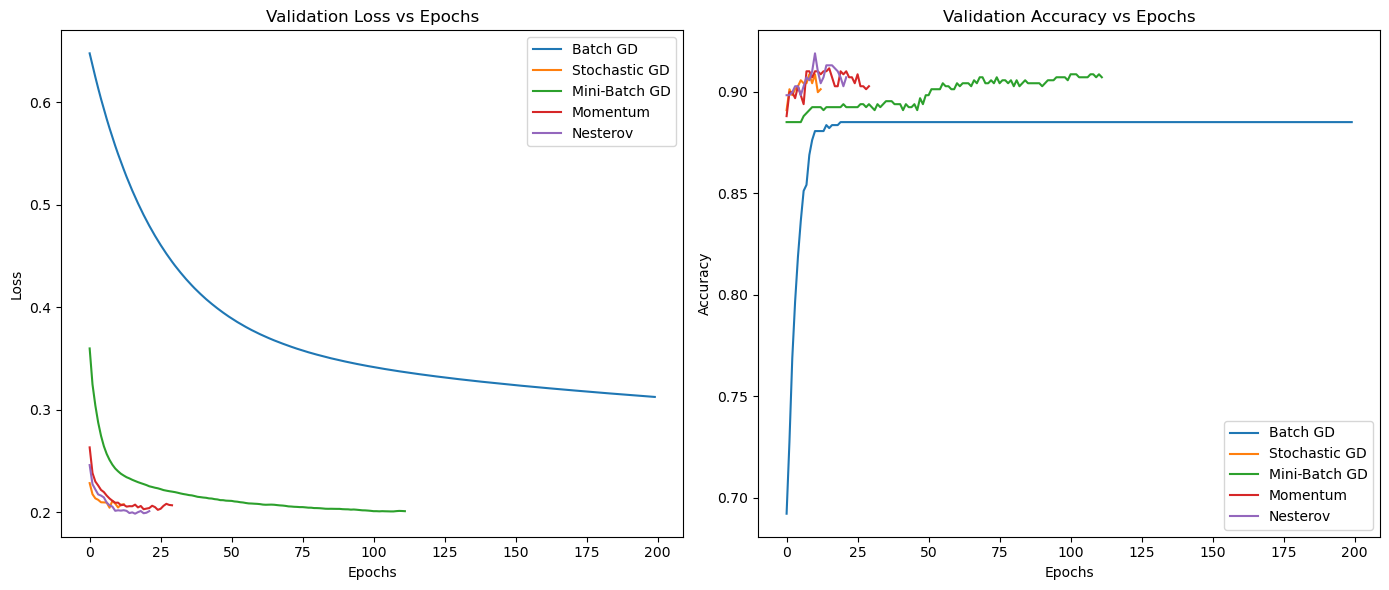

Training Mini-Batch GD with batch size 16...
Training Mini-Batch GD with batch size 32...
Training Mini-Batch GD with batch size 64...


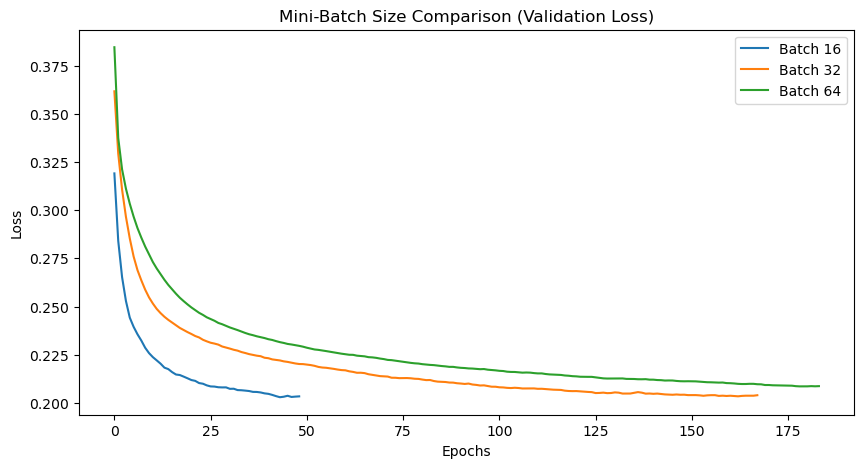

Training SGD with learning rate 0.1...
Training SGD with learning rate 0.01...
Training SGD with learning rate 0.001...


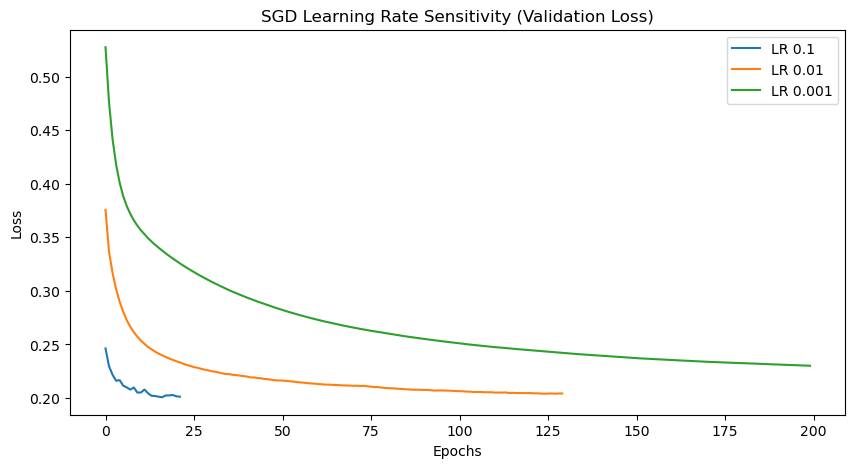

Training Momentum with momentum 0.5...
Training Nesterov with momentum 0.5...
Training Momentum with momentum 0.9...
Training Nesterov with momentum 0.9...
Training Momentum with momentum 0.99...
Training Nesterov with momentum 0.99...


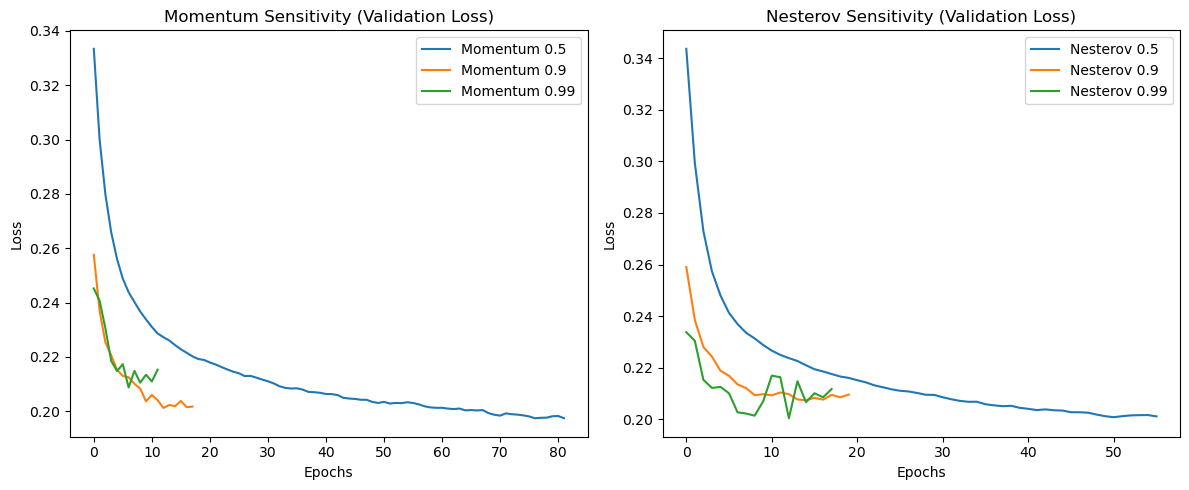

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

Best Optimizer: Nesterov
Test Accuracy: 0.8984
Test Precision: 0.5818
Test Recall: 0.4103
Test F1-score: 0.4812
Confusion Matrix:
 [[578  23]
 [ 46  32]]

Optimizer Comparison Summary:
       Optimizer  Final Train Loss  Final Val Loss  Best Val Accuracy  \
0       Batch GD          0.331606        0.312520           0.885125   
1  Stochastic GD          0.204505        0.207727           0.908689   
2  Mini-Batch GD          0.215875        0.201043           0.908689   
3       Momentum          0.187297        0.206811           0.911635   
4       Nesterov          0.201778        0.201075           0.918999   

   Training Time (s)  
0          33.008157  
1         129.259140  
2          59.964702  
3          17.515301  
4          12.948520  


In [1]:
# Experiment: Evaluation of Optimization Techniques in Deep Neural Networks
# Dataset: Bank Marketing (UCI)
# Uses: Batch GD, SGD, Mini-Batch GD, Momentum, Nesterov
# Includes: Early stopping, batch size experiment, hyperparameter sensitivity, final test evaluation

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import SGD

# -----------------------------
# 1. Reproducibility
# -----------------------------
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# -----------------------------
# 2. Load Dataset
# -----------------------------
data_path = r"Z:\bank details.csv"  # YOUR DATASET PATH

if not os.path.exists(data_path):
    raise FileNotFoundError("Dataset not found at Z:\\bank details.csv")

df = pd.read_csv(data_path, sep=',')

print("Columns in dataset:", df.columns.tolist())

# -----------------------------
# 3. Target Variable
# -----------------------------
TARGET = 'y'
if TARGET not in df.columns:
    raise ValueError(" Target column 'y' not found.")

df[TARGET] = df[TARGET].map({'yes': 1, 'no': 0, 'Yes': 1, 'No': 0})

# -----------------------------
# 4. Preprocessing
# -----------------------------
X = df.drop(columns=[TARGET])
y = df[TARGET]

categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# Fit-transform entire dataset
X_processed = preprocessor.fit_transform(X)

# -----------------------------
# 5. Train / Validation / Test Split (70 / 15 / 15)
# -----------------------------
X_temp, X_test, y_temp, y_test = train_test_split(
    X_processed, y, test_size=0.15, random_state=SEED, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=SEED, stratify=y_temp
)  # 0.1765 of 85% ≈ 15%

input_dim = X_train.shape[1]

# -----------------------------
# 6. Model Architecture
# -----------------------------
from tensorflow.keras.layers import Input

def build_model():
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    return model



# -----------------------------
# 7. Training Function
# -----------------------------
def train_model(optimizer, batch_size):
    model = build_model()
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    start_time = time.time()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        batch_size=batch_size,
        epochs=200,
        callbacks=[early_stop],
        verbose=0
    )
    training_time = time.time() - start_time

    return model, history, training_time

# -----------------------------
# 8. Optimizer Configurations
# -----------------------------
optimizers = {
    "Batch GD": SGD(learning_rate=0.01),
    "Stochastic GD": SGD(learning_rate=0.01),
    "Mini-Batch GD": SGD(learning_rate=0.01),
    "Momentum": SGD(learning_rate=0.01, momentum=0.9),
    "Nesterov": SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
}

batch_sizes = {
    "Batch GD": X_train.shape[0],
    "Stochastic GD": 1,
    "Mini-Batch GD": 32,
    "Momentum": 32,
    "Nesterov": 32
}

results = {}

# -----------------------------
# 9. Train All Optimizers
# -----------------------------
for name, optimizer in optimizers.items():
    print(f"Training with {name}...")
    model, history, train_time = train_model(
        optimizer, batch_sizes[name]
    )
    results[name] = {
        "model": model,
        "history": history,
        "time": train_time
    }

# -----------------------------
# 10. Plot Loss and Validation Accuracy
# -----------------------------
plt.figure(figsize=(14, 6))

# Validation Loss
plt.subplot(1, 2, 1)
for name, res in results.items():
    plt.plot(res["history"].history['val_loss'], label=name)
plt.title("Validation Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# Validation Accuracy
plt.subplot(1, 2, 2)
for name, res in results.items():
    plt.plot(res["history"].history['val_accuracy'], label=name)
plt.title("Validation Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

# -----------------------------
# 11. Mini-Batch Size Experiment
# -----------------------------
mini_batch_sizes = [16, 32, 64]
mini_batch_results = {}

for bs in mini_batch_sizes:
    print(f"Training Mini-Batch GD with batch size {bs}...")
    optimizer = SGD(learning_rate=0.01)
    model, history, train_time = train_model(optimizer, bs)
    mini_batch_results[bs] = {
        "model": model,
        "history": history,
        "time": train_time
    }

plt.figure(figsize=(10, 5))
for bs, res in mini_batch_results.items():
    plt.plot(res["history"].history['val_loss'], label=f"Batch {bs}")
plt.title("Mini-Batch Size Comparison (Validation Loss)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# -----------------------------
# 12. Hyperparameter Sensitivity
# -----------------------------
# Learning rate sensitivity for SGD
learning_rates = [0.1, 0.01, 0.001]
sgd_lr_results = {}

for lr in learning_rates:
    print(f"Training SGD with learning rate {lr}...")
    optimizer = SGD(learning_rate=lr)
    model, history, train_time = train_model(optimizer, 32)
    sgd_lr_results[lr] = {
        "model": model,
        "history": history,
        "time": train_time
    }

plt.figure(figsize=(10, 5))
for lr, res in sgd_lr_results.items():
    plt.plot(res["history"].history['val_loss'], label=f"LR {lr}")
plt.title("SGD Learning Rate Sensitivity (Validation Loss)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Momentum coefficient sensitivity
momentum_values = [0.5, 0.9, 0.99]
momentum_results = {}
nesterov_results = {}

for m in momentum_values:
    print(f"Training Momentum with momentum {m}...")
    optimizer = SGD(learning_rate=0.01, momentum=m)
    model, history, train_time = train_model(optimizer, 32)
    momentum_results[m] = {
        "model": model,
        "history": history,
        "time": train_time
    }

    print(f"Training Nesterov with momentum {m}...")
    optimizer = SGD(learning_rate=0.01, momentum=m, nesterov=True)
    model, history, train_time = train_model(optimizer, 32)
    nesterov_results[m] = {
        "model": model,
        "history": history,
        "time": train_time
    }

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for m, res in momentum_results.items():
    plt.plot(res["history"].history['val_loss'], label=f"Momentum {m}")
plt.title("Momentum Sensitivity (Validation Loss)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
for m, res in nesterov_results.items():
    plt.plot(res["history"].history['val_loss'], label=f"Nesterov {m}")
plt.title("Nesterov Sensitivity (Validation Loss)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

# -----------------------------
# 13. Final Evaluation on Test Set (Best Optimizer)
# -----------------------------
best_name = None
best_val_acc = 0

for name, res in results.items():
    val_acc = max(res["history"].history['val_accuracy'])
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_name = name

best_model = results[best_name]["model"]

# Predict on test set
y_test_pred_prob = best_model.predict(X_test).ravel()
y_test_pred = (y_test_pred_prob >= 0.5).astype(int)

# Metrics
acc = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred)
rec = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
cm = confusion_matrix(y_test, y_test_pred)

print("\nBest Optimizer:", best_name)
print(f"Test Accuracy: {acc:.4f}")
print(f"Test Precision: {prec:.4f}")
print(f"Test Recall: {rec:.4f}")
print(f"Test F1-score: {f1:.4f}")
print("Confusion Matrix:\n", cm)

# -----------------------------
# 14. Summary Table
# -----------------------------
summary = []

for name, res in results.items():
    history = res["history"]
    summary.append({
        "Optimizer": name,
        "Final Train Loss": history.history['loss'][-1],
        "Final Val Loss": history.history['val_loss'][-1],
        "Best Val Accuracy": max(history.history['val_accuracy']),
        "Training Time (s)": res["time"]
    })

summary_df = pd.DataFrame(summary)
print("\nOptimizer Comparison Summary:")
print(summary_df)
